In [1]:
#Part 1: Data Loading and Preparation (Corrected)
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    df = pd.read_csv("final_preprocessed_dataset.csv")
    print(f"Dataset loaded. Original shape: {df.shape}")
except FileNotFoundError:
    print("ERROR: 'final_preprocessed_dataset.csv' file not found.")
    exit()

# NaN Fix: Remove the null values 'Depression' column
original_count = len(df)
df.dropna(subset=['Depression'], inplace=True)
print(f"Removed {original_count - len(df)} rows with missing 'Depression' values.")

X = df.drop('Depression', axis=1)
y = df['Depression']
print("Data loading and preparation complete.")

Dataset loaded. Original shape: (22301, 30)
Removed 0 rows with missing 'Depression' values.
Data loading and preparation complete.


In [2]:
#Part 2: Data Splitting and Feature Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scales the features of the dataset for better model performance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled.")

Data successfully split and scaled.


In [3]:
# Part 3: Define Model "Varieties" (Logistic Regression)
from sklearn.linear_model import LogisticRegression

# C-regularization strength
lr_var1 = LogisticRegression(C=0.1, solver='liblinear', random_state=42)
lr_var2 = LogisticRegression(C=1.0, solver='liblinear', random_state=42)
lr_var3 = LogisticRegression(C=10.0, solver='liblinear', random_state=42)

# List the three models
models = [lr_var1, lr_var2, lr_var3]
model_names = ['Logistic Regression (C=0.1)', 'Logistic Regression (C=1.0)', 'Logistic Regression (C=10.0)']

print("Defined 3 varieties for Logistic Regression.")

Defined 3 varieties for Logistic Regression.


In [4]:
# Part 4: Train and Evaluate All 3 Varieties
from sklearn.metrics import classification_report, confusion_matrix, f1_score

results = {}

for model, name in zip(models, model_names):
    print(f"--- Training and Evaluating: {name} ---")

    # 1. Train the model
    model.fit(X_train_scaled, y_train)

    # 2. Create predictions for test data
    y_pred = model.predict(X_test_scaled)

    # 3. Evaluation Matrix (Classification Report)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Depression', 'Depression']))

    # 4. Evaluation Matrix (Confusion Matrix)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # 5.Save F1-Score to compare
    f1 = f1_score(y_test, y_pred, average='weighted')
    results[name] = f1
    print(f"Weighted F1-Score: {f1:.4f}")
    print("---------------------------------------------------\n")

--- Training and Evaluating: Logistic Regression (C=0.1) ---

Classification Report:
               precision    recall  f1-score   support

No Depression       0.83      0.78      0.80      2751
   Depression       0.85      0.89      0.87      3940

     accuracy                           0.84      6691
    macro avg       0.84      0.83      0.84      6691
 weighted avg       0.84      0.84      0.84      6691

Confusion Matrix:
[[2154  597]
 [ 451 3489]]
Weighted F1-Score: 0.8427
---------------------------------------------------

--- Training and Evaluating: Logistic Regression (C=1.0) ---

Classification Report:
               precision    recall  f1-score   support

No Depression       0.83      0.78      0.80      2751
   Depression       0.85      0.89      0.87      3940

     accuracy                           0.84      6691
    macro avg       0.84      0.83      0.84      6691
 weighted avg       0.84      0.84      0.84      6691

Confusion Matrix:
[[2153  598]
 [ 451 34

--- Comparison of Member 1's Varieties ---
Logistic Regression (C=0.1): 0.8427
Logistic Regression (C=1.0): 0.8425
Logistic Regression (C=10.0): 0.8425

Conclusion: The best variety for Logistic Regression is 'Logistic Regression (C=0.1)'.

 Individual comparison chart saved to 'member_1_varieties_chart.png'
Text summary saved to 'member_1_results.txt'


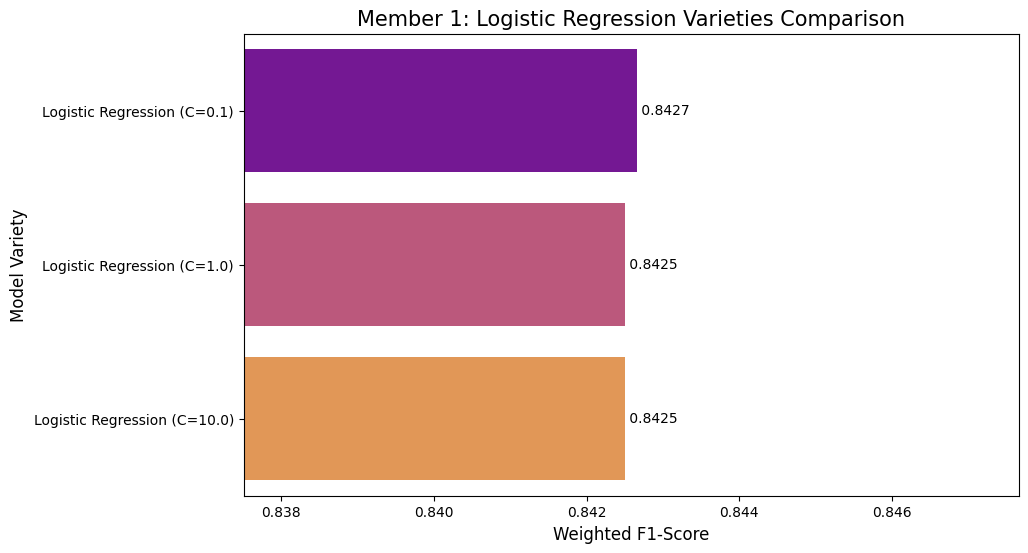

In [5]:
#Part 5: Final Conclusion, Save Text & Create Chart
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Find the Best model according to F1-Score
best_model_name = max(results, key=results.get)
best_f1_score = results[best_model_name]

print(f"--- Comparison of Member 1's Varieties ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

print(f"\nConclusion: The best variety for Logistic Regression is '{best_model_name}'.")

# INDIVIDUAL GRAPHIC OUTPUT

# 2. Prepare the data create the chart
df_member1 = pd.DataFrame(list(results.items()), columns=['Variety', 'F1-Score'])

# 3. Bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Variety', data=df_member1, palette='plasma')
plt.title('Member 1: Logistic Regression Varieties Comparison', fontsize=15)
plt.xlabel('Weighted F1-Score', fontsize=12)
plt.ylabel('Model Variety', fontsize=12)
plt.xlim(min(df_member1['F1-Score']) - 0.005, max(df_member1['F1-Score']) + 0.005) # Zoom for clarity

# values
for index, value in enumerate(df_member1['F1-Score']):
    plt.text(value, index, f' {value:.4f}', va='center')

# 4. Save the chart in image
chart_filename = "member_1_varieties_chart.png"
plt.savefig(chart_filename)
print(f"\n Individual comparison chart saved to '{chart_filename}'")

# 5.Create the text file
file_content = f"""
--- MEMBER 1: FINAL OPTIMUM RESULT ---
Model: Logistic Regression
Optimum Variety: {best_model_name}
Final Weighted F1-Score for Group Comparison: {best_f1_score:.4f}
--- Details of All Varieties Tested ---
"""
for name, score in results.items():
    file_content += f"{name}: {score:.4f}\n"

text_filename = "member_1_results.txt"
with open(text_filename, 'w') as f:
    f.write(file_content)

print(f"Text summary saved to '{text_filename}'")